In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import itertools

In [2]:
transform = transforms.Compose([
    transforms.Resize([64, 64]),
    transforms.Grayscale(1),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5], std = [0.5])
])

In [3]:
dataset = datasets.ImageFolder('../astro_dataset', transform = transform)
train_sz = int(len(dataset) * 0.8)
train_dataset, val_dataset = random_split(dataset, [train_sz, len(dataset) - train_sz])

In [4]:
print(dataset.class_to_idx)
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}')

{'galaxy': 0, 'star': 1}
Train: 3188, Val: 798


In [5]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = True)

In [6]:
def visualize(image):

    def denormalize(im):
        return im * 0.5 + 0.5
    
    im = denormalize(image[0]).permute(1, 2, 0)
    cl = image[1]
    plt.imshow(im.numpy(), cmap = 'inferno')
    plt.title(dataset.classes[cl])
    plt.axis('off')

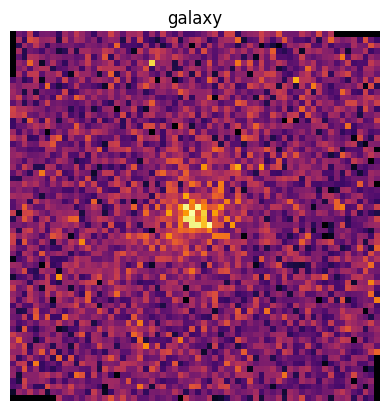

In [7]:
visualize(dataset[0])

In [8]:
batch_size = 32
channel_num = 1
image_height = 64
image_width = 64
patch_size = 8
embed_size = 32
blocks_num = 2
classes_num = 1 # binary classification
hidden_layer = 128
num_head = 2
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
class FeedForward(nn.Module):

    def __init__(self, embed_size):
        super().__init__()
        self.linear1 = nn.Linear(embed_size, embed_size * 4)
        self.act = nn.SiLU()
        self.linear2 = nn.Linear(embed_size * 4, embed_size)

    def forward(self, x):
        x = self.act(self.linear1(x)) # (batch_size, num_patches, embed_size) -> (batch_size, num_patches, embed_size * 4)
        x = self.linear2(x) # (batch_size, num_patches, embed_size * 4) -> (batch_size, num_patches, embed_size)
        return x

class TransformerBlock(nn.Module):

    def __init__(self, embed_size, num_head):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_size)
        self.attn = nn.MultiheadAttention(embed_size, num_head, batch_first = True)
        self.norm2 = nn.LayerNorm(embed_size)
        self.ff = FeedForward(embed_size)
    
    def forward(self, x):
        norm_x = self.norm1(x) # (batch_size, num_patches, embed_size) -> (batch_size, num_patches, embed_size)
        attn_x = self.attn(key = norm_x, query = norm_x, value = norm_x)[0] 
        x = x + attn_x # (batch_size, num_patches, embed_size) -> (batch_size, num_patches, embed_size)
        x = self.ff(self.norm2(x)) + x # (batch_size, num_patches, embed_size) -> (batch_size, num_patches, embed_size)
        return x

class MLPClassificationHead(nn.Module):

    def __init__(self, embed_size, hidden_layer, classes_num):
        super().__init__()
        self.linear1 = nn.Linear(embed_size, hidden_layer)
        self.silu = nn.SiLU()
        self.linear2  = nn.Linear(hidden_layer, classes_num)
    
    def forward(self, x):
        x = self.linear1(x) # (batch_size, embed_size) -> (batch_size, hidden_layer)
        x = self.linear2(self.silu(x)) # (batch_size, hidden_layer) -> (batch_size, classes_num)
        return x


class ViT(nn.Module):

    def __init__(self, batch_size, channel_num, image_height, image_width,  patch_size, embed_size, blocks_num, classes_num, hidden_layer, num_head):
        super().__init__()
        p_height = image_height // patch_size
        p_width = image_width // patch_size
        patches_num = p_height * p_width
        self.patches_num = patches_num
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.p_height = p_height
        self.p_width = p_width
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_size))
        self.pos_enc = nn.Embedding(patches_num + 1, embed_size)
        self.linear1 = nn.Linear(channel_num * patch_size * patch_size, embed_size)
        self.transformer_blocks = nn.Sequential(*[TransformerBlock(embed_size, num_head) for _ in range(blocks_num)])
        self.mlp_head = MLPClassificationHead(embed_size, hidden_layer, classes_num)
    
    def forward(self, x): # x - (batch_size, channels, height, width)
        B, C, H, W = x.shape
        x = x.reshape(B, C, self.p_height, self.patch_size, self.p_width, self.patch_size) 
        x = x.permute(0, 2, 4, 3, 5, 1)
        x = x.reshape(B, self.patches_num, (self.patch_size ** 2) * C)
        x = self.linear1(x) # (B, patches_num, patch_size ** 2 * C) -> (B, patches_num, embed_size)
        x = torch.cat([self.cls_token.expand(B, -1, -1), x], dim = 1)
        x = x + self.pos_enc(torch.arange(self.patches_num + 1).to(device)) # (B, patches_num, embed_size) + (patches_num, embed_size) -> (B, patches_num, embed_size)
        x = self.transformer_blocks(x)
        cls_out = x[:, 0] # (B, embed_size)
        logits = self.mlp_head(cls_out)
        if logits.shape[1] == 1:
            logits = logits.flatten(0, -1)
        return logits

In [10]:
model = ViT(batch_size, channel_num, image_height, image_width, patch_size, embed_size, blocks_num, classes_num, hidden_layer, num_head)
print(f'Total number of parameters: {sum(p.numel() for p in model.parameters())}')

Total number of parameters: 33953


In [11]:
n_galaxy = 942
n_star = 3044

In [12]:
@torch.no_grad()
def get_stats(loader, criterion, num_batches = 10):
    total_num = 0
    total_correct = 0
    total_loss = 0
    model.eval()
    for batch, labels in itertools.islice(loader, num_batches):
        logits = model(batch)
        loss = criterion(logits, labels.float())
        total_num += len(batch)
        total_loss += len(batch) * loss.item()
        total_correct += (torch.abs(torch.sigmoid(logits) - labels) < 0.5).sum().item()
    model.train()
    return total_loss / total_num, total_correct / total_num

In [15]:
EPOCHS = 100
optimizer = torch.optim.Adam(model.parameters(), lr = 5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = EPOCHS)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([n_galaxy / n_star]))
model.train()
stats_every = 10

train_accuracy = []
train_losses = []
val_accuracy = []
val_losses = []

for epoch in range(1, EPOCHS+1):
    for batch, labels in train_loader:
        logits = model(batch)
        loss = criterion(logits, labels.float())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    tr_loss, tr_acc = get_stats(train_loader, criterion, num_batches=len(train_loader))
    val_loss, val_acc = get_stats(val_loader, criterion, num_batches=len(val_loader))
    train_accuracy.append(tr_acc)
    train_losses.append(tr_loss)
    val_accuracy.append(val_acc)
    val_losses.append(val_loss)
    if epoch % stats_every == 0:
        print(f'Epoch {epoch}/{EPOCHS}:')
        print('-'*50)
        print(f'TRAIN: Loss {tr_loss}, Accuracy {tr_acc * 100}%')
        print(f'VAL: Loss {val_loss}, Accuracy {val_acc * 100}%')
        
    scheduler.step()

Epoch 10/100:
--------------------------------------------------
TRAIN: Loss 0.2698777611910773, Accuracy 82.34002509410288%
VAL: Loss 0.2650634548568487, Accuracy 83.0827067669173%
Epoch 20/100:
--------------------------------------------------
TRAIN: Loss 0.2229714016319069, Accuracy 78.23086574654955%
VAL: Loss 0.22204205244406125, Accuracy 78.32080200501254%
Epoch 30/100:
--------------------------------------------------
TRAIN: Loss 0.2443392846074278, Accuracy 83.1555834378921%
VAL: Loss 0.24620126555662109, Accuracy 83.33333333333334%
Epoch 40/100:
--------------------------------------------------
TRAIN: Loss 0.1904595559334366, Accuracy 82.12045169385195%
VAL: Loss 0.21055870519993, Accuracy 79.82456140350878%
Epoch 50/100:
--------------------------------------------------
TRAIN: Loss 0.18632548796001314, Accuracy 81.99498117942284%
VAL: Loss 0.1954431896819208, Accuracy 80.7017543859649%
Epoch 60/100:
--------------------------------------------------
TRAIN: Loss 0.18551488

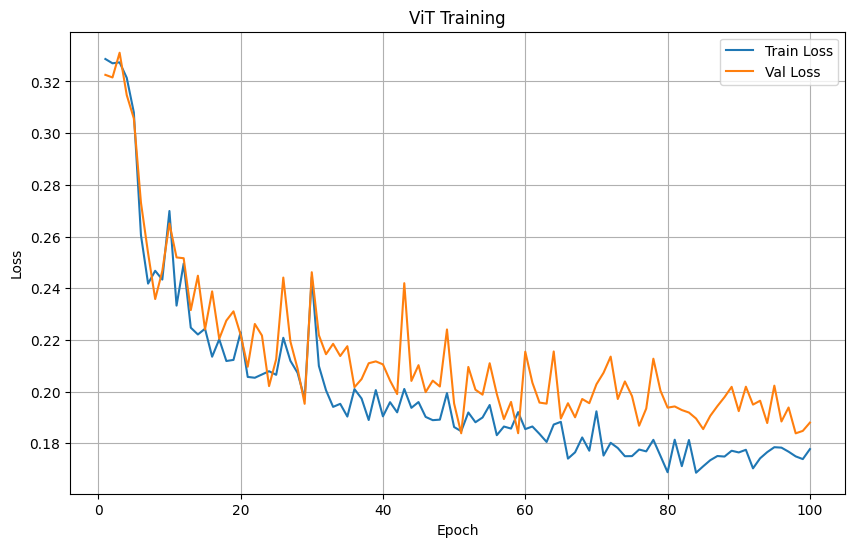

In [16]:
plt.figure(figsize = (10, 6))
plt.title('ViT Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(torch.arange(len(train_losses)) + 1, train_losses, label = 'Train Loss');
plt.plot(torch.arange(len(val_losses)) + 1, val_losses, label = 'Val Loss');
plt.grid()
plt.legend()
plt.show()

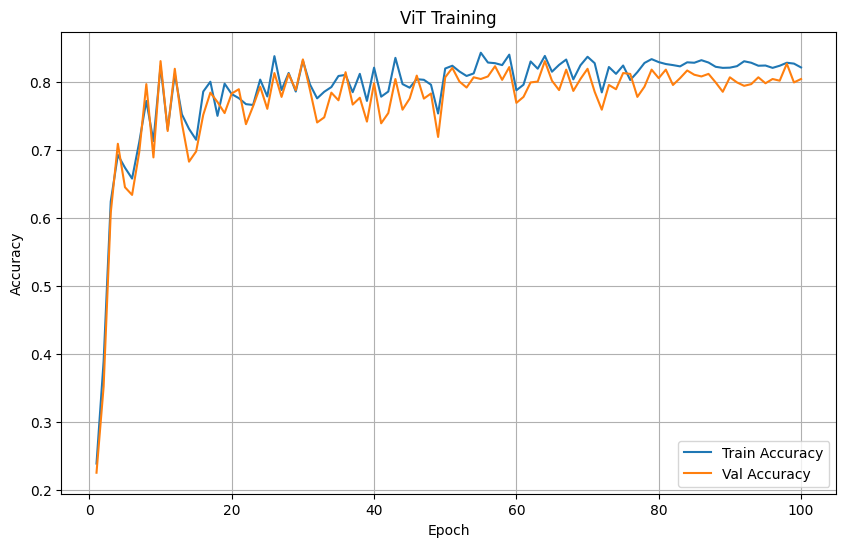

In [17]:
plt.figure(figsize = (10, 6))
plt.title('ViT Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(torch.arange(len(train_losses)) + 1, train_accuracy, label = 'Train Accuracy');
plt.plot(torch.arange(len(val_losses)) + 1, val_accuracy, label = 'Val Accuracy');
plt.grid()
plt.legend()
plt.show()

              precision    recall  f1-score   support

      galaxy       0.55      0.84      0.67       180
        star       0.94      0.80      0.87       618

    accuracy                           0.81       798
   macro avg       0.75      0.82      0.77       798
weighted avg       0.86      0.81      0.82       798



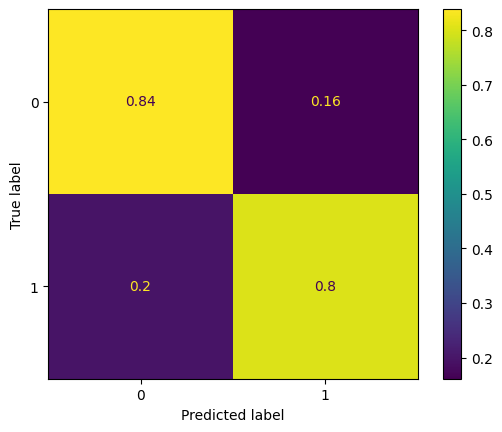

In [18]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

model.eval()
all_preds = []
all_labels = []
all_logits = []
with torch.no_grad():
    for images, labels in val_loader:
        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long()
        all_logits.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['galaxy', 'star']))
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, normalize='true');

In [19]:
from sklearn.metrics import precision_recall_curve

probs = torch.sigmoid(torch.tensor(all_logits))
precisions, recalls, thresholds = precision_recall_curve(all_labels, probs, pos_label=0)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold = thresholds[f1_scores[:-1].argmax()]
print(f"Оптимальный порог: {best_threshold}")

Оптимальный порог: 0.5007399916648865
